In [1]:
from ESN import Reservoir
from narma import NARMA
from Qreservoir_fast import QReservoir
from tools import gen_input_states, gen_config_filepath, gen_system_filepath, gen_result_filepath, write_to_row, finish_row, unpack_config, folder_name

import numpy as np
import matplotlib.pyplot as plt
import os

#Pyörittelyt --------------------------------------------------------

In [2]:
classic = Reservoir(128)
classic.add_performance_task(NARMA(degree_=6))
classic.generate_inputs([1000,3000,5000])
classic.evolve_reservoir('task1', 'full')
classic.results['task1']

Added performance task 'NARMA(6, 0.3, 0.05, 0.375, 0)' as 'task1'


('NARMA(6, 0.3, 0.05, 0.375, 0)', np.float64(0.010377221203816078))

In [ ]:
for i in range(50):
    jeps = Reservoir(128, 0.9, 0.1)
    jeps.add_performance_task(NARMA(degree_=6))
    jeps.generate_inputs([1000,5000,3000])
    jeps.evolve_reservoir('task1', 'full')
    print(jeps.results['task1'])

In [11]:
gamma, reservoir_size, fock_truncation, reservoir_connectivity, sim_rounding, n_models, n_train_inputs, n_test_inputs = unpack_config("Qreservoir_configurations/config3.json")

In [3]:
QReservoir_models = [QReservoir(gamma, reservoir_size, fock_truncation, reservoir_connectivity, sim_rounding) for _ in range(n_models)]
train_inputs = np.array([gen_input_states("sq_th", n_train_inputs, fock_truncation, sim_rounding) for _ in range(n_models)])

for Qreservoir in QReservoir_models:
    Qreservoir.init_reservoir("vacuum")
    Qreservoir.rk4_timesteps(4)

In [4]:
test_inputs_sq_th = np.array([gen_input_states("sq_th", n_test_inputs, fock_truncation, sim_rounding) for _ in range(n_models)])
test_inputs_sq_pho_add = np.array([gen_input_states("pho_add", n_test_inputs, fock_truncation, sim_rounding) for _ in range(n_models)])
test_inputs_sq_pho_sub = np.array([gen_input_states("pho_sub", n_test_inputs, fock_truncation, sim_rounding) for _ in range(n_models)])
test_inputs_simple = np.array([gen_input_states("simple", n_test_inputs, fock_truncation, sim_rounding) for _ in range(n_models)])

In [ ]:
for i in range(n_models):
    QReservoir_models[i].train_reservoir(train_inputs[i])
    systempath = gen_system_filepath(folder_name(gamma, reservoir_size, fock_truncation, reservoir_connectivity), i)
    QReservoir_models[i].system_save(systempath)

tr_res: (1+0j)
tr_new: (0.999999999983+0j)
0
tr_res: (1+0j)
tr_new: (1.000000003112+0j)
tr_res: (1.0000001192092896+0j)
tr_new: (1.000000163441+0j)
tr_res: (1.000000238418579+0j)
tr_new: (1.000000170484+0j)
tr_res: (1.0000001192092896+0j)
tr_new: (1.00000014423+0j)
tr_res: (1.0000001192092896+0j)
tr_new: (1.000000092443+0j)
tr_res: (1.000000238418579+0j)
tr_new: (1.000000183509+0j)
tr_res: (1.000000238418579+0j)
tr_new: (1.000000220314+0j)
tr_res: (1.0000001192092896+0j)
tr_new: (1.0000001266260001+0j)
tr_res: (1.0000001192092896+0j)
tr_new: (1.000000167137+0j)
tr_res: (1.0000001192092896+0j)
tr_new: (1.000000090557+0j)
tr_res: (1+0j)
tr_new: (1.000000063392+0j)
tr_res: (1+0j)
tr_new: (1.000000033462+0j)
tr_res: (1+0j)
tr_new: (1.0000000259300001+0j)
tr_res: (1+0j)
tr_new: (0.9999999957369999+0j)
tr_res: (0.9999998807907104+0j)
tr_new: (0.9999999505799999+0j)
tr_res: (0.9999998807907104+0j)
tr_new: (0.999999882203+0j)
tr_res: (1+0j)
tr_new: (0.999999970855+0j)
tr_res: (1+0j)
tr_new: (0

In [7]:
QReservoir_models[7] = QReservoir(gamma, reservoir_size, fock_truncation, reservoir_connectivity, sim_rounding)
train_inputs[7] = gen_input_states("sq_th", n_train_inputs, fock_truncation, sim_rounding)

QReservoir_models[7].init_reservoir("vacuum")
QReservoir_models[7].rk4_timesteps(4)

In [9]:
QReservoir_models[7].train_reservoir(train_inputs[7])
systempath = gen_system_filepath(folder_name(gamma, reservoir_size, fock_truncation, reservoir_connectivity), 7)
QReservoir_models[7].system_save(systempath)

tr_res: (1+0j)
tr_new: (0.999999999988+0j)
0
tr_res: (0.9999998807907104+0j)
tr_new: (0.9999998597469999+0j)
tr_res: (0.9999998807907104+0j)
tr_new: (0.9999998102050001+0j)
tr_res: (0.9999996423721313+0j)
tr_new: (0.9999996454169999+0j)
tr_res: (0.9999995231628418+0j)
tr_new: (0.9999995779640001+0j)
tr_res: (0.9999995231628418+0j)
tr_new: (0.9999995217850001+0j)
tr_res: (0.9999995231628418+0j)
tr_new: (0.9999995794130001+0j)
tr_res: (0.9999995231628418+0j)
tr_new: (0.9999995654739999+0j)
tr_res: (0.999999463558197+0j)
tr_new: (0.9999994804679999+0j)
tr_res: (0.9999995231628418+0j)
tr_new: (0.999999564541+0j)
tr_res: (0.9999995231628418+0j)
tr_new: (0.9999995387629999+0j)
tr_res: (0.9999995231628418+0j)
tr_new: (0.999999578955+0j)
tr_res: (0.9999997019767761+0j)
tr_new: (0.999999669995+0j)
tr_res: (0.9999996423721313+0j)
tr_new: (0.9999996601269999+0j)
tr_res: (0.9999995827674866+0j)
tr_new: (0.999999611612+0j)
tr_res: (0.999999463558197+0j)
tr_new: (0.9999994765600001+0j)
tr_res: (0.99

In [14]:
resultpath = gen_result_filepath(folder_name(gamma, reservoir_size, fock_truncation, reservoir_connectivity))

In [16]:
res = QReservoir_models[0].analyze_performance(QReservoir_models[0].test_Y_true, QReservoir_models[0].test_Y_pred)
write_to_row(str(res), resultpath)

In [17]:
for i in range(1,n_models):
    QReservoir_models[i].reset_after_test()
    result = QReservoir_models[i].test_reservoir(test_inputs_sq_th[i])
    write_to_row(str(result), resultpath)

finish_row(resultpath)

tr_res: (1.0000015497207642+0j)
tr_new: (1.0000016542019998+0j)
0
tr_res: (1.0000016689300537+0j)
tr_new: (1.000001649337+0j)
tr_res: (1.0000016689300537+0j)
tr_new: (1.0000016837389998+0j)
tr_res: (1.0000016689300537+0j)
tr_new: (1.0000016234909999+0j)
tr_res: (1.0000016689300537+0j)
tr_new: (1.000001649519+0j)
tr_res: (1.0000016689300537+0j)
tr_new: (1.000001572696+0j)
tr_res: (1.0000014305114746+0j)
tr_new: (1.000001479257+0j)
tr_res: (1.0000015497207642+0j)
tr_new: (1.0000015131+0j)
tr_res: (1.0000014305114746+0j)
tr_new: (1.0000014601190002+0j)
tr_res: (1.0000015497207642+0j)
tr_new: (1.00000150526+0j)
tr_res: (1.0000014305114746+0j)
tr_new: (1.000001447352+0j)
tr_res: (1.0000014305114746+0j)
tr_new: (1.000001374667+0j)
tr_res: (1.0000014305114746+0j)
tr_new: (1.000001379594+0j)
tr_res: (1.000001311302185+0j)
tr_new: (1.000001309371+0j)
tr_res: (1.000001311302185+0j)
tr_new: (1.000001346432+0j)
tr_res: (1.0000014305114746+0j)
tr_new: (1.0000014284399998+0j)
tr_res: (1.000001311302

In [18]:
for i in range(n_models):
    QReservoir_models[i].reset_after_test()
    result = QReservoir_models[i].test_reservoir(test_inputs_sq_pho_add[i])
    write_to_row(str(result), resultpath)

finish_row(resultpath)

tr_res: (0.9999988079071045+0j)
tr_new: (0.9999987994309999+0j)
0
tr_res: (0.9999988079071045+0j)
tr_new: (0.9999987997840001+0j)
tr_res: (0.999998927116394+0j)
tr_new: (0.999998913113+0j)
tr_res: (0.9999988079071045+0j)
tr_new: (0.9999988709149998+0j)
tr_res: (0.9999988079071045+0j)
tr_new: (0.999998819341+0j)
tr_res: (0.9999988079071045+0j)
tr_new: (0.999998754149+0j)
tr_res: (0.9999988079071045+0j)
tr_new: (0.9999987649759999+0j)
tr_res: (0.9999988079071045+0j)
tr_new: (0.9999987779520001+0j)
tr_res: (0.9999988079071045+0j)
tr_new: (0.9999987799319999+0j)
tr_res: (0.9999986886978149+0j)
tr_new: (0.999998663196+0j)
tr_res: (0.9999986886978149+0j)
tr_new: (0.9999987252179999+0j)
tr_res: (0.9999988079071045+0j)
tr_new: (0.99999883791+0j)
tr_res: (0.9999988079071045+0j)
tr_new: (0.9999988382889999+0j)
tr_res: (0.9999988675117493+0j)
tr_new: (0.9999988276009999+0j)
tr_res: (0.9999988675117493+0j)
tr_new: (0.999998847277+0j)
tr_res: (0.9999988675117493+0j)
tr_new: (0.9999988849120001+0j)


KeyboardInterrupt: 

In [ ]:
for i in range(n_models):
    QReservoir_models[i].reset_after_test()
    result = QReservoir_models[i].test_reservoir(test_inputs_sq_pho_sub[i])
    write_to_row(str(result), resultpath)

finish_row(resultpath)

In [ ]:
for i in range(n_models):
    QReservoir_models[i].reset_after_test()
    result = QReservoir_models[i].test_reservoir(test_inputs_simple[i])
    write_to_row(str(result), resultpath)

finish_row(resultpath)

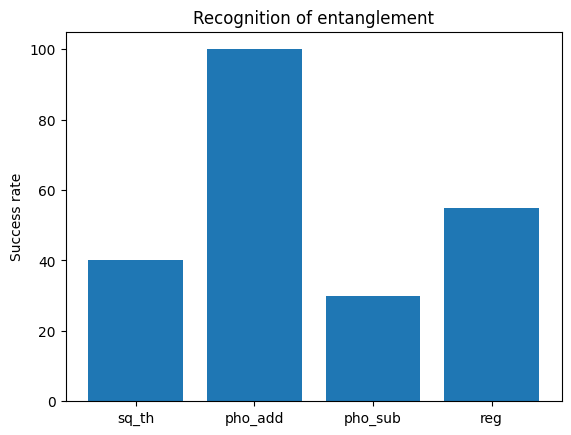

In [ ]:
#Plot the probability of correct classification
fig, ax = plt.subplots()

input_types = ['sq_th', 'pho_add', 'pho_sub', 'reg']
counts = [40, 100, 30, 55]
ax.bar(input_types, counts)

ax.set_ylabel('Success rate')
ax.set_title('Recognition of entanglement')

plt.show()

In [18]:
train_in = gen_input_states("sq_th", 20, fock_truncation, sim_rounding)

test_pho_add = gen_input_states("pho_add", 1000, fock_truncation)
test_pho_sub = gen_input_states("pho_sub", 1000, fock_truncation)
test_simple = gen_input_states("simple", 1000, fock_truncation)

In [ ]:
Qres1 = QReservoir(gamma, reservoir_size, fock_truncation, reservoir_connectivity, sim_rounding)
Qres1.init_reservoir("vacuum")
Qres1.rk4_timesteps(4)

In [9]:
Qres1.train_reservoir(train_in)

tr_res: (1+0j)
tr_new: (0.99999999999+0j)
0
tr_res: (1.0000001192092896+0j)
tr_new: (1.000000006256+0j)
tr_res: (1+0j)
tr_new: (1.000000016474+0j)
tr_res: (1+0j)
tr_new: (1.000000031781+0j)
tr_res: (1.0000001192092896+0j)
tr_new: (1.0000000827039999+0j)
tr_res: (1+0j)
tr_new: (1.000000031157+0j)
tr_res: (1.0000001192092896+0j)
tr_new: (1.000000092539+0j)
tr_res: (1.000000238418579+0j)
tr_new: (1.000000201162+0j)
tr_res: (1.0000001192092896+0j)
tr_new: (1.000000122081+0j)
tr_res: (0.9999998807907104+0j)
tr_new: (0.999999883691+0j)
tr_res: (0.9999998211860657+0j)
tr_new: (0.999999896657+0j)
tr_res: (0.9999998211860657+0j)
tr_new: (0.9999998775910001+0j)
tr_res: (0.9999997019767761+0j)
tr_new: (0.9999996913350001+0j)
tr_res: (0.9999997019767761+0j)
tr_new: (0.999999709024+0j)
tr_res: (0.9999997019767761+0j)
tr_new: (0.999999662833+0j)
tr_res: (0.9999997615814209+0j)
tr_new: (0.9999996969010001+0j)
tr_res: (0.9999997615814209+0j)
tr_new: (0.9999997459780001+0j)
tr_res: (0.9999997019767761+

In [10]:
result = Qres1.test_reservoir(test_simple)


tr_res: (0.9999996423721313+0j)
tr_new: (0.9999997615814209-3.2760003598752974e-09j)
0
tr_res: (0.9999997615814209-3.2629998703015417e-09j)
tr_new: (0.9999997615814209-9.457999716744325e-09j)
tr_res: (0.9999997019767761-9.45999989454549e-09j)
tr_new: (0.9999998211860657-1.0814999562569483e-08j)
tr_res: (0.9999997019767761-1.0842000186528367e-08j)
tr_new: (0.9999998211860657-1.0906001435273538e-08j)
tr_res: (0.9999997615814209-1.0909999126340608e-08j)
tr_new: (0.9999997615814209-1.9815999507954984e-08j)
tr_res: (0.9999998211860657-1.980099995080309e-08j)
tr_new: (0.9999997615814209-2.3876999932781473e-08j)
tr_res: (0.9999998211860657-2.3873999666079726e-08j)
tr_new: (0.9999998211860657-2.3475999810784742e-08j)
tr_res: (0.9999997615814209-2.3509999280690863e-08j)
tr_new: (0.9999996423721313-2.1019001650302016e-08j)
tr_res: (0.9999996423721313-2.1036001385255076e-08j)
tr_new: (0.9999996423721313-2.3687999117782965e-08j)
tr_res: (0.9999995827674866-2.368099849547889e-08j)
tr_new: (0.999999

In [14]:
from tools import init_destroy, init_identity, tensor, dagger, init_two_mode_sq, init_vac, assess_dm_entanglement, init_simple

In [20]:
def get_entanglement_values(inputs):
    return np.array([[1,0] if assess_dm_entanglement(input, "first", fock_truncation, fock_truncation, 2) > 0 else [0,1] for input in inputs])

In [30]:
for input in test_inputs_simple[0]:
    print(assess_dm_entanglement(input, "first", fock_truncation, fock_truncation, 5))


0.96755
0.87519
0.99894
0.88835
0.96696
0.69145
0.85646
0.96579
0.77236
0.56685
0.71857
0.93866
0.91144
0.99695
0.9566
0.61496
0.80229
0.99967
0.62662
0.74656
0.83138
0.39272
0.99992
0.48011
0.99836
0.63106
0.3915
0.88783
0.61662
0.91286
0.98898
0.93042
0.98985
0.94825
0.99831
0.99382
0.60674
0.10465
0.99958
0.6883
0.60528
0.563
0.99337
0.94346
0.77607
0.88817
0.98082
0.99071
0.98198
0.95253
0.96305
0.94671
0.56702
0.98235
0.7738
0.98408
0.82261
0.58686
0.71439
0.99434
0.98797
0.87566
0.93965
0.83503
0.90649
0.15478
0.64391
0.99999
0.95589
0.94509
0.85277
0.46142
0.99498
0.99328
0.51858
0.99768
0.85251
0.96551
0.64911
0.98221
0.77635
0.75925
0.83453
0.8623
0.93417
0.98078
0.89529
0.61028
0.83704
0.9703
0.88809
0.75495
0.94075
0.46816
0.3422
0.94717
0.95762
0.92229
0.98492
0.91716
0.99972
0.51289
0.97178
0.97156
0.84382
0.90723
0.78147
0.94043
0.76904
0.814
0.98728
0.70684
0.60147
0.95206
0.91448
0.55158
0.96962
0.97986
0.94156
0.84461
0.57257
0.8916
0.94979
0.70054
0.6893
0.87959
0.999

In [27]:
truncate = 5
amount_of_states = 10000

a1 = tensor([init_destroy(truncate), init_identity(truncate)])
a2 = tensor([init_identity(truncate), init_destroy(truncate)])
        
abs_alpha_pho_add_ = np.random.uniform(0.1, 0.25, (amount_of_states,))
theta_pho_add_ = np.random.uniform(0,2*np.pi,(amount_of_states,))
alpha_pho_add_ = np.array([x*np.exp(1j*y) for x, y in zip(abs_alpha_pho_add_,theta_pho_add_)])  

abs_alpha_pho_sub_ = np.random.uniform(0.8, 0.95, (amount_of_states,))
theta_pho_sub_ = np.random.uniform(0,2*np.pi,(amount_of_states,))
alpha_pho_sub_ = np.array([x*np.exp(1j*y) for x, y in zip(abs_alpha_pho_sub_,theta_pho_sub_)])

theta_simple_ = np.array([np.arcsin(np.sqrt(x)) for x in np.random.uniform(0,1,(amount_of_states,))])
phi_simple_ = np.random.uniform(0,2*np.pi,(amount_of_states,))
c0_simple_ = np.array([np.sin(x) for x in theta_simple_])
c1_simple_ = np.array([np.cos(x)*np.exp(1j*y) for x,y in zip(theta_simple_, phi_simple_)])

In [30]:
counter = 0
for c0, c1 in zip(c0_simple_,c1_simple_):
    if np.abs(c0**2-np.abs(c1**2)) > 0.5:
        counter += 1
print(counter)

5096
